<a href="https://colab.research.google.com/github/jewon6273-creator/quant-/blob/main/formation_backtest_colab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ 포메이션 전술 백테스트 (Colab)

시장 온도에 따라 포트폴리오를 **3-4-3 / 4-2-3-1 / 5-2-3** 으로 바꾸는 규칙이 실제로 도움이 되는지 과거 데이터로 검증합니다.

| 역할 | 자산 |
|---|---|
| 수비 (DF) | 신한지주, 현금 |
| 미드 (MF) | 알파벳 |
| 공격 (FW) | HPE, 노키아, 현대모비스 |

숫자 1칸 = 비중 10% (예: 3-4-3 = 신한 30 / 알파벳 40 / 위성 30)

**사용법**
1. 메뉴 **런타임 → 모두 실행** (처음 1회는 한글 폰트 설치 때문에 1분 정도 걸립니다)
2. **② 설정** 셀에서 종목·비중·전환 기준을 바꾼 뒤 → 다시 **런타임 → 모두 실행**
3. 결과는 **④ 실행** 아래에 표와 차트로 나옵니다

> ⚠️ 교육·연구용입니다. 과거 성과는 미래 수익을 보장하지 않습니다.

## ① 환경 준비 (패키지 + 한글 폰트)

In [1]:
import sys, subprocess, os
IN_COLAB = "google.colab" in sys.modules

!pip -q install yfinance

if IN_COLAB and not os.path.exists("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"):
    !apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(f):
        font_manager.fontManager.addfont(f)
        plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline
print("준비 완료 | Colab:", IN_COLAB)

준비 완료 | Colab: True


## ② 설정 ✏️ — 여기만 바꾸면 됩니다
- `ASSETS`: 종목 티커 (한국 주식은 `.KS` / 코스닥 `.KQ`)
- `FORMATIONS`: 포메이션별 목표 비중 (합계 1.0)
- `DEFENSE_FORMATION`: 수비 전환 시 쓸 포메이션 (`"5-2-3"` 또는 `"5-3-2"`)
- `CRASH_DD`, `HOT_RET`, `WARM_RET`: 전술 전환 기준

In [2]:
%%writefile config.py
"""
포메이션 백테스트 설정 파일
- 숫자 1칸 = 비중 10%
- 역할: 수비(DF) = 신한지주 + 현금 / 미드(MF) = 알파벳 / 공격(FW) = 위성 3종목
"""

# ── 선수 명단 (티커 → 통화) ──────────────────────────────
ASSETS = {
    "055550.KS": "KRW",  # 신한지주   (DF)
    "GOOGL":     "USD",  # 알파벳     (MF)
    "HPE":       "USD",  # HPE        (FW 좌측 윙)
    "NOK":       "USD",  # 노키아     (FW 중앙)
    "012330.KS": "KRW",  # 현대모비스 (FW 우측 윙)
}
CASH = "CASH"             # 현금 (연 CASH_RATE 이자로 불어남)
FX_TICKER = "KRW=X"       # USD → KRW 환율 (모든 자산을 원화로 평가)

NAMES = {
    "055550.KS": "신한지주", "GOOGL": "알파벳", "HPE": "HPE",
    "NOK": "노키아", "012330.KS": "현대모비스", CASH: "현금",
}

# ── 포메이션 = 목표 비중 ─────────────────────────────────
FORMATIONS = {
    # 기본·공격: 신한 30 / 알파벳 40 / 위성 30
    "3-4-3": {"055550.KS": .30, "GOOGL": .40, "HPE": .10, "NOK": .10, "012330.KS": .10, CASH: .00},
    # 지공(과열·횡보): 현금 10 확보, 알파벳 30
    "4-2-3-1": {"055550.KS": .30, CASH: .10, "GOOGL": .30, "HPE": .10, "NOK": .10, "012330.KS": .10},
    # 수비(뚜렷한 과열): 현금 20, 알파벳 20, 위성 유지
    "5-2-3": {"055550.KS": .30, CASH: .20, "GOOGL": .20, "HPE": .10, "NOK": .10, "012330.KS": .10},
    # 대안 수비: 위성을 줄이고 알파벳 유지
    "5-3-2": {"055550.KS": .30, CASH: .20, "GOOGL": .30, "HPE": .10, "NOK": .10, "012330.KS": .00},
}
DEFENSE_FORMATION = "5-2-3"   # "5-3-2" 로 바꿔서 비교해 보세요

# 비교용 고정 전략
STATIC_BASELINES = {
    "고정 3-4-3": FORMATIONS["3-4-3"],
    "원래 플랜 (알파벳70·신한30)": {"GOOGL": .70, "055550.KS": .30},
}

# ── 전술 전환 신호 ───────────────────────────────────────
SIGNAL_TICKER = "^GSPC"      # 시장 온도계 (S&P500). "^KS11"(코스피), "ACWI" 등으로 교체 가능
SIGNAL_CURRENCY = "USD"
LOOKBACK_DAYS = 252          # 12개월
CRASH_DD = -0.20             # 고점 대비 -20% 이하 → 역습(3-4-3)
HOT_RET = 0.30               # 12개월 +30% 이상 → 수비
WARM_RET = 0.15              # 12개월 +15% 이상 → 지공(4-2-3-1)

# ── 실행 조건 ───────────────────────────────────────────
START = "2016-01-01"         # HPE 상장(2015.11) 이후
END = None                   # None = 오늘까지
REBALANCE_FREQ = "QE"        # "QE" 분기말 점검 / "ME" 월말 점검
REBALANCE_BAND = 0.05        # 포메이션이 같고 비중 이탈이 5%p 미만이면 거래 생략
COST_BPS = 25                # 편도 거래비용 (수수료+슬리피지+환전), 0.25%
CASH_RATE = 0.03             # 현금 연 이자율
RISK_FREE = 0.03             # 샤프지수 계산용 무위험 수익률
INITIAL_CAPITAL = 10_000_000 # 원


Writing config.py


## ③ 엔진 코드 (수정 불필요)
데이터 로딩 → 전술 판단 → 백테스트 → 결과 출력. 전환 규칙을 바꾸고 싶으면 `strategy.py`의 `choose_formation()`을 수정하세요.

In [3]:
%%writefile data.py
"""
데이터 로딩: yfinance 로 받아 원화로 환산하고 캐시에 저장.
--demo 모드에서는 인터넷 없이 가상 데이터로 파이프라인만 검증.
"""
from pathlib import Path

import numpy as np
import pandas as pd

import config as C

CACHE = Path(__file__).parent / "data_cache"


def _download(tickers, start, end) -> pd.DataFrame:
    import yfinance as yf

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    px = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
    if isinstance(px, pd.Series):
        px = px.to_frame(tickers[0])
    missing = [t for t in tickers if t not in px.columns or px[t].dropna().empty]
    if missing:
        raise RuntimeError(f"다운로드 실패: {missing} (인터넷 연결 또는 티커 확인)")
    return px


def load_prices(start=C.START, end=C.END, refresh=False) -> tuple[pd.DataFrame, pd.Series]:
    """(자산 원화 가격표, 시장 신호 지수) 반환. 배당 포함 수정주가 기준."""
    CACHE.mkdir(exist_ok=True)
    f = CACHE / f"prices_{start}_{end or 'today'}.parquet"
    if f.exists() and not refresh:
        px = pd.read_parquet(f)
    else:
        tickers = list(C.ASSETS) + [C.FX_TICKER, C.SIGNAL_TICKER]
        px = _download(tickers, start, end)
        px.to_parquet(f)
    return _to_krw(px)


def _to_krw(px: pd.DataFrame):
    # 한국·미국 휴장일이 달라서 앞의 값으로 채움 (미래 값으로 채우지 않음 = look-ahead 방지)
    px = px.sort_index().ffill()
    fx = px[C.FX_TICKER]
    out = {}
    for t, ccy in C.ASSETS.items():
        out[t] = px[t] * fx if ccy == "USD" else px[t]
    prices = pd.DataFrame(out)
    # 현금: 매일 이자 누적
    days = prices.index.to_series().diff().dt.days.fillna(0)
    prices[C.CASH] = (1 + C.CASH_RATE) ** (days.cumsum() / 365)
    signal = px[C.SIGNAL_TICKER]
    return prices.dropna(how="all"), signal


# ── 데모용 가상 데이터 ───────────────────────────────────
def demo_prices(start="2016-01-01", years=10, seed=4):
    """실제 수익률이 아닌 가상 경로. 코드 검증용으로만 사용."""
    rng = np.random.default_rng(seed)
    idx = pd.bdate_range(start, periods=252 * years)
    n = len(idx)
    params = {  # (연 기대수익, 연 변동성)
        "055550.KS": (0.08, 0.25), "GOOGL": (0.15, 0.30), "HPE": (0.10, 0.38),
        "NOK": (0.05, 0.40), "012330.KS": (0.07, 0.32), "_MKT": (0.10, 0.18),
    }
    market = rng.normal(0, 1, n)
    # 두 번의 폭락 구간 삽입 (시장 신호 규칙 확인용)
    shock = np.zeros(n)
    for s in (int(n * .42), int(n * .65)):
        shock[s:s + 40] = -0.0025
    data = {}
    for t, (mu, vol) in params.items():
        beta = 0.9 if t == "_MKT" else rng.uniform(.5, .8)
        eps = beta * market + np.sqrt(1 - beta**2) * rng.normal(0, 1, n)
        r = mu / 252 - .5 * (vol**2) / 252 + vol / np.sqrt(252) * eps + shock * (vol / .2)
        data[t] = 100 * np.exp(np.cumsum(r))
    df = pd.DataFrame(data, index=idx)
    signal = df.pop("_MKT")
    days = df.index.to_series().diff().dt.days.fillna(0)
    df[C.CASH] = (1 + C.CASH_RATE) ** (days.cumsum() / 365)
    return df, signal


Writing data.py


In [4]:
%%writefile strategy.py
"""
전술 판단: 시장 온도(12개월 수익률, 고점 대비 낙폭)를 보고 포메이션을 고른다.
규칙을 바꾸고 싶으면 choose_formation() 만 수정하면 된다.
"""
import pandas as pd

import config as C


def market_state(signal: pd.Series) -> pd.DataFrame:
    s = signal.dropna()
    return pd.DataFrame({
        "ret_12m": s / s.shift(C.LOOKBACK_DAYS) - 1,
        "drawdown": s / s.rolling(C.LOOKBACK_DAYS, min_periods=20).max() - 1,
    })


def choose_formation(ret_12m: float, drawdown: float) -> str:
    """
    - 폭락(고점 대비 -20% 이하)  → 3-4-3  역습: 쌓아둔 현금 투입
    - 과열(12개월 +30% 이상)      → 수비    (config.DEFENSE_FORMATION)
    - 온기(12개월 +15% 이상)      → 4-2-3-1 지공: 현금 10% 확보
    - 그 외                       → 3-4-3  기본
    """
    if pd.isna(ret_12m) or pd.isna(drawdown):
        return "3-4-3"
    if drawdown <= C.CRASH_DD:
        return "3-4-3"
    if ret_12m >= C.HOT_RET:
        return C.DEFENSE_FORMATION
    if ret_12m >= C.WARM_RET:
        return "4-2-3-1"
    return "3-4-3"


def formation_schedule(signal: pd.Series, dates: pd.DatetimeIndex) -> pd.Series:
    """각 점검일에 쓸 포메이션. asof = 그날까지 알 수 있는 정보만 사용."""
    st = market_state(signal)
    out = {}
    for d in dates:
        row = st.loc[:d].iloc[-1] if not st.loc[:d].empty else None
        out[d] = "3-4-3" if row is None else choose_formation(row.ret_12m, row.drawdown)
    return pd.Series(out, name="formation")


Writing strategy.py


In [5]:
%%writefile engine.py
"""
백테스트 엔진
- 점검일(분기말) 종가로 신호 판단 → 다음 거래일 종가에 리밸런싱 (당일 정보로 당일 매매 금지)
- 리밸런싱 사이에는 비중이 가격에 따라 흘러감(drift)
- 아직 상장 전이거나 가격이 없는 자산의 비중은 현금으로 대기
"""
from dataclasses import dataclass

import numpy as np
import pandas as pd

import config as C


@dataclass
class Result:
    equity: pd.Series          # 일별 자산가치
    weights: pd.DataFrame      # 일별 실제 비중
    trades: pd.DataFrame       # 리밸런싱 기록
    formation: pd.Series       # 일별 포메이션


def check_dates(index: pd.DatetimeIndex, freq: str) -> pd.DatetimeIndex:
    """각 기간의 마지막 거래일."""
    s = pd.Series(index, index=index)
    return pd.DatetimeIndex(s.groupby(pd.Grouper(freq=freq)).last().dropna().values)


def run(prices: pd.DataFrame, targets: pd.Series | dict, cost_bps=C.COST_BPS,
        band=C.REBALANCE_BAND, capital=C.INITIAL_CAPITAL,
        formations: dict | None = None, freq: str | None = None) -> Result:
    """
    targets: {점검일: 포메이션 이름} Series  또는  고정 비중 dict
    formations: 포메이션 이름 → 비중 (기본: config.FORMATIONS)
    freq: 고정 전략의 리밸런싱 점검 주기 (기본: config.REBALANCE_FREQ)
    """
    formations = formations or C.FORMATIONS
    prices = prices.copy()
    cols = list(prices.columns)
    rets = prices.pct_change(fill_method=None).fillna(0.0)
    idx = prices.index

    checks = check_dates(idx, freq or C.REBALANCE_FREQ)
    if isinstance(targets, dict):  # 고정 전략
        plan = {d: ("고정", targets) for d in checks}
    else:
        plan = {d: (f, formations[f]) for d, f in targets.items()}

    # 점검일 다음 거래일에 실행
    exec_plan = {}
    for d, v in plan.items():
        pos = idx.searchsorted(d, side="right")
        if pos < len(idx):
            exec_plan[idx[pos]] = v
    # 첫날: 미래 점검일의 판단을 끌어오지 않도록 기본 포메이션(또는 고정 비중)으로 시작
    first = idx[0]
    if isinstance(targets, dict):
        exec_plan.setdefault(first, ("고정", targets))
    else:
        exec_plan.setdefault(first, ("3-4-3", formations["3-4-3"]))

    w = pd.Series(0.0, index=cols)
    value = capital
    cur_form = None
    eq, W, F, T = [], [], [], []

    for i, d in enumerate(idx):
        # 1) 하루 수익 반영
        if i > 0:
            growth = (w * (1 + rets.loc[d])).sum()
            value *= growth
            w = (w * (1 + rets.loc[d])) / growth if growth > 0 else w

        # 2) 리밸런싱
        if d in exec_plan:
            name, tgt = exec_plan[d]
            tgt = pd.Series(tgt, dtype=float).reindex(cols).fillna(0.0)
            # 가격이 없는 자산 비중 → 현금
            unavailable = prices.loc[d].isna()
            tgt[C.CASH] += tgt[unavailable].sum()
            tgt[unavailable] = 0.0
            drift = (tgt - w).abs().max()
            if name != cur_form or drift >= band:
                turnover = (tgt - w).abs().sum() / 2
                cost = turnover * 2 * cost_bps / 1e4
                value *= 1 - cost
                T.append({"date": d, "formation": name, "turnover": turnover,
                          "cost_krw": value * cost, "value": value})
                w = tgt
                cur_form = name

        eq.append(value)
        W.append(w.values.copy())
        F.append(cur_form)

    return Result(
        equity=pd.Series(eq, index=idx, name="equity"),
        weights=pd.DataFrame(W, index=idx, columns=cols),
        trades=pd.DataFrame(T),
        formation=pd.Series(F, index=idx, name="formation"),
    )


def metrics(res: Result, rf=C.RISK_FREE) -> dict:
    eq = res.equity
    r = eq.pct_change().dropna()
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1
    vol = r.std() * np.sqrt(252)
    dd = eq / eq.cummax() - 1
    t = res.trades
    return {
        "누적수익률": eq.iloc[-1] / eq.iloc[0] - 1,
        "연복리(CAGR)": cagr,
        "연변동성": vol,
        "샤프지수": (cagr - rf) / vol if vol > 0 else np.nan,
        "최대낙폭(MDD)": dd.min(),
        "칼마비율": cagr / abs(dd.min()) if dd.min() < 0 else np.nan,
        "연평균 회전율": t["turnover"].sum() / years if len(t) else 0.0,
        "전술 변경 횟수": int((res.formation != res.formation.shift()).sum() - 1),
    }


Writing engine.py


In [6]:
%%writefile run.py
"""
실행:
    python run.py            # 실제 데이터 (yfinance, 인터넷 필요)
    python run.py --demo     # 가상 데이터로 코드만 검증
    python run.py --refresh  # 캐시 무시하고 다시 다운로드
결과: output/ 폴더에 요약표(csv), 일별 기록(csv), 차트(png)
"""
import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import config as C
import engine
import strategy
from data import demo_prices, load_prices

OUT = Path(__file__).parent / "output"
COLORS = {"3-4-3": "#2e7d32", "4-2-3-1": "#f9a825", "5-2-3": "#c62828", "5-3-2": "#6a1b9a"}


def set_korean_font():
    from matplotlib import font_manager
    for name in ("AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "NanumGothic",
                 "Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Serif CJK KR", "Noto Serif CJK JP"):
        if any(f.name == name for f in font_manager.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False


def backtest_all(prices, signal):
    """전술 전략 + 비교 대상들을 한 번에 실행. {이름: Result} 반환."""
    checks = engine.check_dates(prices.index, C.REBALANCE_FREQ)
    schedule = strategy.formation_schedule(signal, checks)
    results = {"포메이션 전술": engine.run(prices, schedule)}
    for name, w in C.STATIC_BASELINES.items():
        results[name] = engine.run(prices, w)
    return results


def format_summary(summary: pd.DataFrame) -> pd.DataFrame:
    fmt = summary.copy()
    for c in ["누적수익률", "연복리(CAGR)", "최대낙폭(MDD)", "연평균 회전율"]:
        fmt[c] = fmt[c].map(lambda x: f"{x:+.1%}")
    fmt["연변동성"] = fmt["연변동성"].map(lambda x: f"{x:.1%}")
    for c in ["샤프지수", "칼마비율"]:
        fmt[c] = fmt[c].map(lambda x: f"{x:.2f}")
    fmt["전술 변경 횟수"] = fmt["전술 변경 횟수"].astype(int)
    return fmt


def main(demo=False, refresh=False, verbose=True):
    """노트북에서는 main(demo=True) 처럼 직접 호출. (summary, results, fig) 반환."""
    OUT.mkdir(exist_ok=True)
    prices, signal = demo_prices() if demo else load_prices(refresh=refresh)

    results = backtest_all(prices, signal)
    summary = pd.DataFrame({k: engine.metrics(v) for k, v in results.items()}).T
    if verbose:
        print("\n=== 결과 요약", "(가상 데이터)" if demo else "", "===")
        print(format_summary(summary).to_string())

    tactic = results["포메이션 전술"]
    share = tactic.formation.value_counts(normalize=True).map("{:.0%}".format)
    if verbose:
        print("\n포메이션별 시간 비중:", dict(share))

    summary.to_csv(OUT / "summary.csv", encoding="utf-8-sig")
    daily = pd.concat([tactic.equity, tactic.formation,
                       tactic.weights.rename(columns=C.NAMES).add_prefix("w_")], axis=1)
    daily.to_csv(OUT / "tactic_daily.csv", encoding="utf-8-sig")
    tactic.trades.to_csv(OUT / "tactic_trades.csv", index=False, encoding="utf-8-sig")

    fig = plot(results, demo)
    if verbose:
        print(f"\n저장 완료 → {OUT}/")
    return summary, results, fig


def plot(results, demo):
    set_korean_font()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.3]})
    tactic = results["포메이션 전술"]

    # 배경에 포메이션 구간 색칠
    f = tactic.formation
    blocks = (f != f.shift()).cumsum()
    for _, seg in f.groupby(blocks):
        ax1.axvspan(seg.index[0], seg.index[-1], color=COLORS.get(seg.iloc[0], "#999"),
                    alpha=0.08, lw=0)

    for name, r in results.items():
        eq = r.equity / r.equity.iloc[0]
        ax1.plot(eq, lw=2.2 if name == "포메이션 전술" else 1.3, label=name)
        ax2.plot(r.equity / r.equity.cummax() - 1, lw=1.1)

    handles = ax1.get_legend_handles_labels()[0]
    used = [k for k in COLORS if k in set(f)]
    patches = [plt.Rectangle((0, 0), 1, 1, color=COLORS[k], alpha=.25) for k in used]
    ax1.legend(handles + patches, list(results) + [f"구간: {k}" for k in used],
               loc="upper left", fontsize=9, ncol=2)
    ax1.set_ylabel("자산 (시작=1)")
    ax1.set_title("포메이션 전술 백테스트" + (" — 가상 데이터" if demo else ""))
    ax1.grid(alpha=.3)
    ax2.set_ylabel("고점 대비 낙폭")
    ax2.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax2.grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(OUT / "equity.png", dpi=140)
    return fig


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--demo", action="store_true")
    ap.add_argument("--refresh", action="store_true")
    a = ap.parse_args()
    main(demo=a.demo, refresh=a.refresh)


Writing run.py


## ④ 실행
- `DEMO = True` : 인터넷 없이 가상 데이터로 동작만 확인
- `DEMO = False`: Yahoo Finance 실제 데이터 (기본값)
- `REFRESH = True`: 저장된 데이터를 무시하고 새로 다운로드

📊 성과 비교


,누적수익률,연복리(CAGR),연변동성,샤프지수,최대낙폭(MDD),칼마비율,연평균 회전율,전술 변경 횟수
포메이션 전술,+544.0%,+19.0%,17.9%,0.89,-32.4%,0.59,+35.3%,14
고정 3-4-3,+608.4%,+20.0%,19.0%,0.90,-34.6%,0.58,+20.6%,0
원래 플랜 (알파벳70·신한30),+835.8%,+23.2%,22.5%,0.90,-30.2%,0.77,+19.1%,0



포메이션별 시간 비중: {'3-4-3': '56%', '4-2-3-1': '37%', '5-2-3': '7%'}


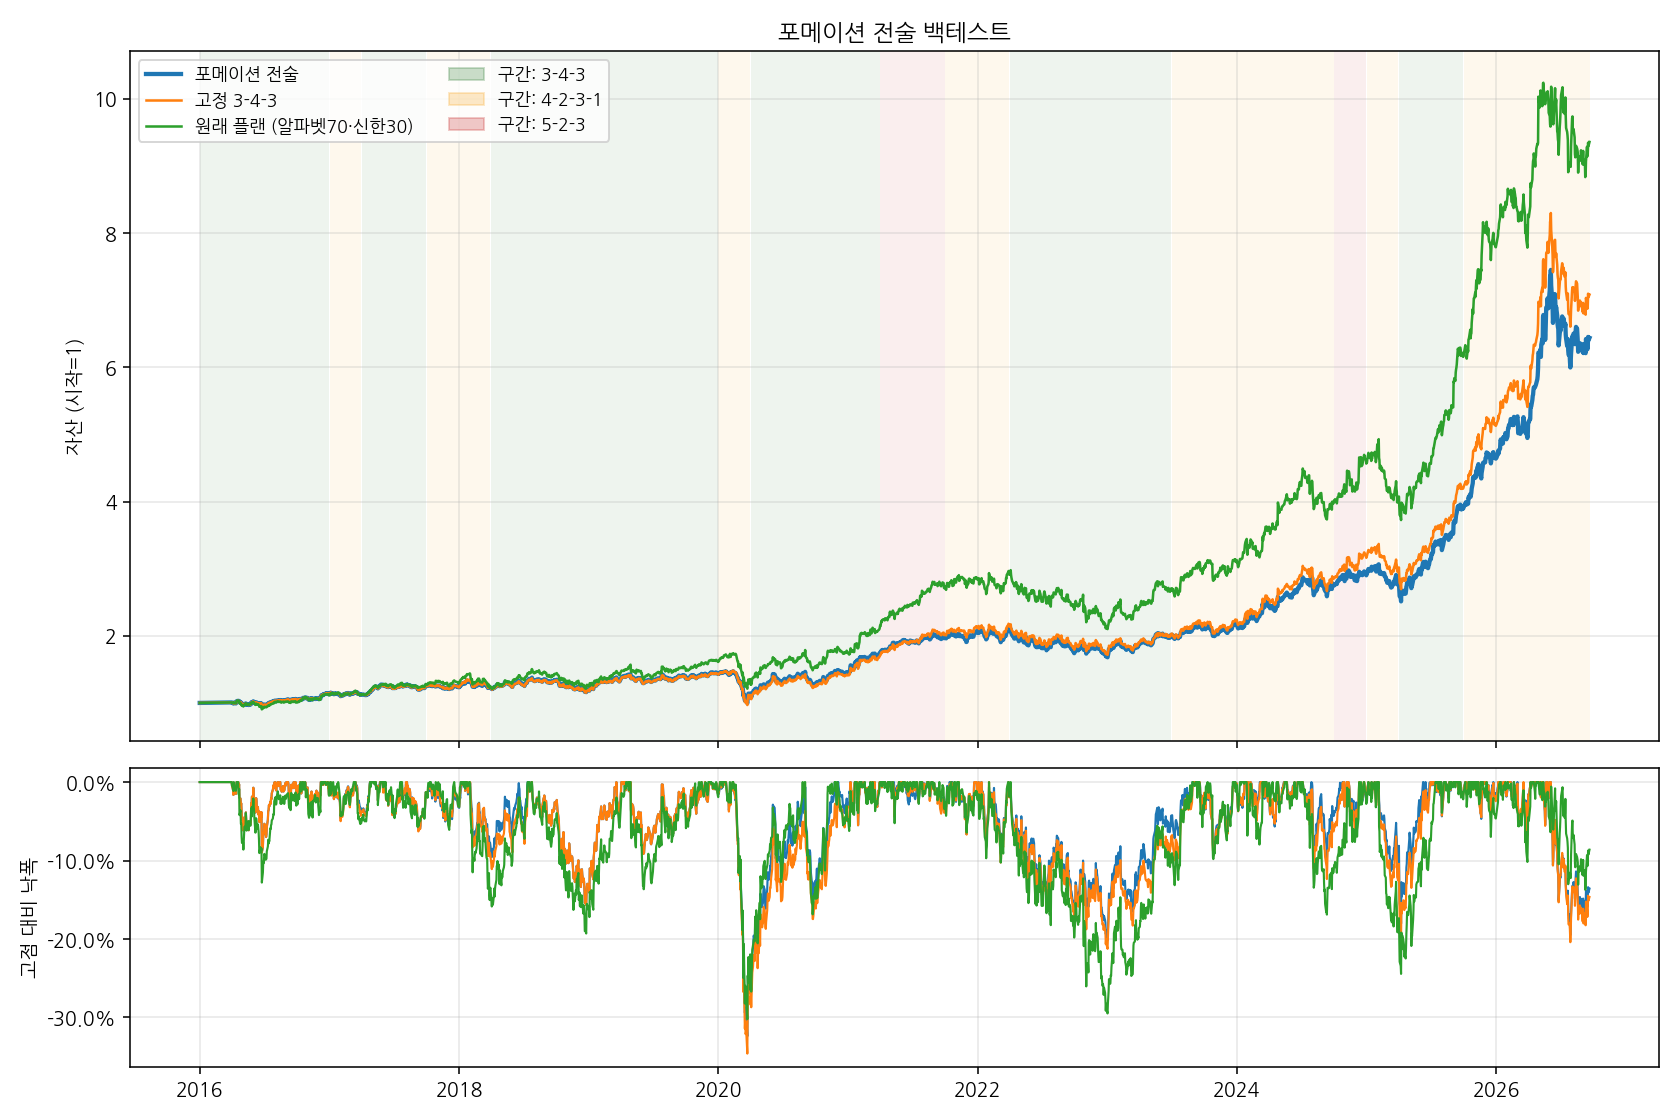

In [7]:
DEMO = False
REFRESH = False

import importlib, config, data, strategy, engine, run
for m in (config, data, strategy, engine, run):
    importlib.reload(m)          # ② 설정 변경 사항 반영

summary, results, fig = run.main(demo=DEMO, refresh=REFRESH, verbose=False)
plt.close(fig)

from IPython.display import display, Image
print("📊 성과 비교" + (" (가상 데이터)" if DEMO else ""))
display(run.format_summary(summary))
tactic = results["포메이션 전술"]
print("\n포메이션별 시간 비중:",
      tactic.formation.value_counts(normalize=True).map("{:.0%}".format).to_dict())
display(Image(filename="output/equity.png"))

### 전술 전환 기록 (언제 어떤 포메이션으로 바꿨나)

In [8]:
t = results["포메이션 전술"].trades.copy()
t["turnover"] = t["turnover"].map("{:.1%}".format)
t["cost_krw"] = t["cost_krw"].map("{:,.0f}원".format)
t["value"] = t["value"].map("{:,.0f}원".format)
t.columns = ["실행일", "포메이션", "회전율", "거래비용", "매매 후 자산"]
display(t)

,실행일,포메이션,회전율,거래비용,매매 후 자산
0,2016-01-01,3-4-3,50.0%,"24,937원","9,975,000원"
1,2016-04-01,3-4-3,100.0%,"49,993원","9,998,538원"
2,2017-01-02,4-2-3-1,11.8%,"6,649원","11,272,883원"
3,2017-04-03,3-4-3,11.6%,"6,478원","11,215,434원"
4,2017-10-02,4-2-3-1,12.2%,"7,655원","12,536,397원"
5,2018-04-02,3-4-3,12.3%,"7,436원","12,090,528원"
6,2018-07-02,3-4-3,6.1%,"3,885원","12,673,293원"
7,2020-01-01,4-2-3-1,14.8%,"10,564원","14,287,182원"
8,2020-04-01,3-4-3,14.4%,"7,792원","10,850,756원"
9,2021-04-01,5-2-3,25.6%,"22,358원","17,457,584원"


## ⑤ 민감도 분석 — 이 규칙, 운이 아닐까?
전환 기준을 조금씩 바꿔도 결과가 비슷하면 **튼튼한 규칙**, 특정 값에서만 좋으면 **과최적화(운)** 일 가능성이 큽니다.

In [9]:
import itertools, pandas as pd
prices, signal = data.demo_prices() if DEMO else data.load_prices()
base = {k: getattr(config, k) for k in ["HOT_RET", "CRASH_DD", "DEFENSE_FORMATION"]}

rows = []
for hot, crash, dfn in itertools.product([0.20, 0.25, 0.30, 0.40], [-0.15, -0.20, -0.30], ["5-2-3", "5-3-2"]):
    config.HOT_RET, config.CRASH_DD, config.DEFENSE_FORMATION = hot, crash, dfn
    r = run.backtest_all(prices, signal)["포메이션 전술"]
    m = engine.metrics(r)
    rows.append({"과열 기준": f"+{hot:.0%}", "폭락 기준": f"{crash:.0%}", "수비 포메이션": dfn,
                 "CAGR": m["연복리(CAGR)"], "MDD": m["최대낙폭(MDD)"], "샤프": m["샤프지수"]})
for k, v in base.items():
    setattr(config, k, v)        # 원래 설정 복구

sens = pd.DataFrame(rows)
fixed = engine.metrics(run.backtest_all(prices, signal)["고정 3-4-3"])
print(f"비교 기준 — 고정 3-4-3: CAGR {fixed['연복리(CAGR)']:+.1%}, MDD {fixed['최대낙폭(MDD)']:+.1%}, 샤프 {fixed['샤프지수']:.2f}")
print(f"고정 3-4-3보다 샤프가 높은 조합: {(sens['샤프'] > fixed['샤프지수']).sum()} / {len(sens)}")
display(sens.style.format({"CAGR": "{:+.1%}", "MDD": "{:+.1%}", "샤프": "{:.2f}"})
        .background_gradient(subset=["샤프"], cmap="RdYlGn"))

비교 기준 — 고정 3-4-3: CAGR +20.0%, MDD -34.6%, 샤프 0.90
고정 3-4-3보다 샤프가 높은 조합: 18 / 24


,과열 기준,폭락 기준,수비 포메이션,CAGR,MDD,샤프
0,+20%,-15%,5-2-3,+19.1%,-30.2%,0.93
1,+20%,-15%,5-3-2,+20.1%,-28.1%,0.96
2,+20%,-20%,5-2-3,+19.1%,-30.2%,0.93
3,+20%,-20%,5-3-2,+20.1%,-28.1%,0.96
4,+20%,-30%,5-2-3,+19.1%,-30.2%,0.93
5,+20%,-30%,5-3-2,+20.1%,-28.1%,0.96
6,+25%,-15%,5-2-3,+18.8%,-32.4%,0.89
7,+25%,-15%,5-3-2,+19.8%,-32.4%,0.94
8,+25%,-20%,5-2-3,+18.8%,-32.4%,0.89
9,+25%,-20%,5-3-2,+19.8%,-32.4%,0.94


### ⑤-2 최대낙폭 시점 + 기간 분할 검증
최대낙폭이 언제 났는지, 그리고 앞 5년·뒤 5년에서 각각 규칙이 통했는지 확인합니다.

In [10]:
base = (config.HOT_RET, config.DEFENSE_FORMATION)

def worst(r):
    dd = r.equity / r.equity.cummax() - 1
    low = dd.idxmin(); high = r.equity[:low].idxmax()
    return f"{high.date()} → {low.date()} ({dd.min():+.1%}) | 포메이션 {r.formation[high]} → {r.formation[low]}"

for hot, dfn in [(0.20, "5-3-2"), (0.30, "5-2-3")]:
    config.HOT_RET, config.DEFENSE_FORMATION = hot, dfn
    res = run.backtest_all(prices, signal)
    print(f"과열 +{hot:.0%} / {dfn}:", worst(res["포메이션 전술"]))
print("고정 3-4-3:          ", worst(res["고정 3-4-3"]))

config.HOT_RET, config.DEFENSE_FORMATION = 0.20, "5-3-2"
rows = []
for label, (s, e) in {"2016~2020": ("2016-01-01", "2020-12-31"), "2021~현재": ("2021-01-01", None)}.items():
    res = run.backtest_all(prices.loc[s:e], signal)
    for name in ["포메이션 전술", "고정 3-4-3"]:
        m = engine.metrics(res[name])
        rows.append({"기간": label, "전략": name, "CAGR": m["연복리(CAGR)"],
                     "MDD": m["최대낙폭(MDD)"], "샤프": m["샤프지수"]})
config.HOT_RET, config.DEFENSE_FORMATION = base
display(pd.DataFrame(rows).style.format({"CAGR": "{:+.1%}", "MDD": "{:+.1%}", "샤프": "{:.2f}"}))

과열 +20% / 5-3-2: 2020-02-12 → 2020-03-23 (-28.1%) | 포메이션 5-3-2 → 5-3-2
과열 +30% / 5-2-3: 2020-02-12 → 2020-03-23 (-32.4%) | 포메이션 4-2-3-1 → 4-2-3-1
고정 3-4-3:           2020-02-12 → 2020-03-23 (-34.6%) | 포메이션 고정 → 고정


,기간,전략,CAGR,MDD,샤프
0,2016~2020,포메이션 전술,+8.7%,-28.1%,0.35
1,2016~2020,고정 3-4-3,+7.2%,-34.6%,0.24
2,2021~현재,포메이션 전술,+31.0%,-20.2%,1.48
3,2021~현재,고정 3-4-3,+33.2%,-20.4%,1.50


## ⑥ 장기 검증 (2000년~) — 규칙 자체가 통하는가?
위 결과는 폭락이 코로나 1번뿐이라 결론을 내기 어려웠습니다. 여기서는 **개별 종목 대신 대체 ETF**로 바꿔서 2000년부터 검증합니다. 종목 선택 편향이 사라지고, 폭락 사례가 **6번**(닷컴·금융위기·유럽위기·2018·코로나·2022)으로 늘어납니다.

| 자리 | 대체 ETF | 원래 종목 |
|---|---|---|
| 수비 DF | EWY (한국 주식) | 신한지주 |
| 미드 MF | QQQ (나스닥100) | 알파벳 |
| 공격 FW1 | XLK (미국 기술주) | HPE |
| 공격 FW2 | IWM (미국 소형주) | 노키아 |
| 공격 FW3 | XLI (미국 산업재) | 현대모비스 |

**비교하는 전환 규칙 3가지** (수비 포메이션은 앞 결과에서 더 나았던 5-3-2 사용)
- **A 과열 규칙** (지금 규칙): S&P500 12개월 +30% → 수비, +15% → 지공, 고점 대비 -20% → 3-4-3
- **B 추세 규칙**: S&P500이 200일 이동평균선 아래 → 수비, 위 → 3-4-3
- **C 추세+역습**: B + 고점 대비 -25% 이상 폭락 후 50일선 회복(반등 확인) → **2-4-4 공격**

※ 달러 기준(2003년 이전 환율 데이터 부족) · 현금은 미국 3개월 국채 금리 적용 · ETF를 바꾸려면 `longterm.py`의 `PROXY` 수정

In [11]:
%%writefile longterm.py
"""
장기 검증 (2000년~): 개별 종목 대신 대체 ETF로 '전환 규칙 자체'가 통하는지 확인.

- 종목 선택 편향을 없애고, 폭락 사례를 6번 이상 확보하는 것이 목적
- 환율 데이터가 2003년 이전에는 부족해서 모든 자산을 달러 기준으로 평가
- 현금은 미국 3개월 국채 금리(^IRX)만큼 이자가 붙음
"""
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config as C
import engine

START = "2000-06-01"          # EWY·IWM 상장 직후, 닷컴 붕괴 초입
CASH = C.CASH
BENCH = "SPY"                 # 참고용: S&P500 그대로 보유
SIGNAL = "^GSPC"
TBILL = "^IRX"

# 역할 → (대체 ETF, 설명)   ※ 다른 ETF로 바꿔서 실험해 보세요
PROXY = {
    "DF":  ("EWY", "한국 주식 → 신한지주 자리"),
    "MF":  ("QQQ", "나스닥100 → 알파벳 자리"),
    "FW1": ("XLK", "미국 기술주 → HPE 자리"),
    "FW2": ("IWM", "미국 소형주(고위험) → 노키아 자리"),
    "FW3": ("XLI", "미국 산업재 → 현대모비스 자리"),
}

# 역할 기준 포메이션 (숫자 1칸 = 10%)
FORMATIONS = {
    "3-4-3":   {"DF": .30, "MF": .40, "FW1": .10, "FW2": .10, "FW3": .10},
    "4-2-3-1": {"DF": .30, CASH: .10, "MF": .30, "FW1": .10, "FW2": .10, "FW3": .10},
    "5-2-3":   {"DF": .30, CASH: .20, "MF": .20, "FW1": .10, "FW2": .10, "FW3": .10},
    "5-3-2":   {"DF": .30, CASH: .20, "MF": .30, "FW1": .10, "FW2": .10},
    "2-4-4":   {"DF": .20, "MF": .40, "FW1": .40 / 3, "FW2": .40 / 3, "FW3": .40 / 3},  # 역습
}

# 위기(하락장)와 상승장 구간 — S&P500 고점·저점 기준
PERIODS = {
    "📉 닷컴 붕괴":      ("2000-09-01", "2002-10-09"),
    "📉 금융위기":        ("2007-10-09", "2009-03-09"),
    "📉 유럽 재정위기":   ("2011-04-29", "2011-10-03"),
    "📉 2018년 4분기":    ("2018-09-20", "2018-12-24"),
    "📉 코로나":          ("2020-02-19", "2020-03-23"),
    "📉 2022년 긴축":     ("2022-01-03", "2022-10-12"),
    "📈 2003~07 상승장":  ("2002-10-09", "2007-10-09"),
    "📈 2009~20 상승장":  ("2009-03-09", "2020-02-19"),
    "📈 2022~현재 상승장": ("2022-10-12", None),
}

CACHE = Path(__file__).parent / "data_cache"
OUT = Path(__file__).parent / "output"


# ── 데이터 ───────────────────────────────────────────────
def load(demo=False, refresh=False):
    """(역할별 가격표 + CASH + SPY, S&P500 신호) 반환. 달러 기준."""
    if demo:
        return _demo()
    from data import _download

    CACHE.mkdir(exist_ok=True)
    f = CACHE / f"longterm_{START}.parquet"
    if f.exists() and not refresh:
        px = pd.read_parquet(f)
    else:
        tickers = [t for t, _ in PROXY.values()] + [BENCH, SIGNAL, TBILL]
        px = _download(tickers, "1999-01-01", None)   # 신호 계산용으로 1년 앞서 받음
        px.to_parquet(f)
    px = px.sort_index().ffill()

    prices = pd.DataFrame({role: px[t] for role, (t, _) in PROXY.items()})
    prices[BENCH] = px[BENCH]
    # 현금: 전날 3개월 국채 금리로 이자 누적
    days = px.index.to_series().diff().dt.days.fillna(0)
    daily = 1 + px[TBILL].shift(1).fillna(0) / 100 * days / 365
    prices[CASH] = daily.cumprod()
    prices = prices.loc[START:].dropna()
    return prices, px[SIGNAL]


def _demo(seed=11):
    """가상 데이터 (코드 검증용). 실제 위기 구간에 가상 폭락을 넣음."""
    rng = np.random.default_rng(seed)
    idx = pd.bdate_range("1999-01-01", "2026-09-18")
    n = len(idx)
    shock = pd.Series(0.0, index=idx)
    for name, (s, e) in PERIODS.items():
        if name.startswith("📉"):
            shock[s:e] = -0.35 / max(len(shock[s:e]), 1)   # 구간 전체에서 약 -35%
    mkt = rng.normal(0, 1, n)
    spec = {"DF": (.08, .28), "MF": (.12, .30), "FW1": (.10, .26), "FW2": (.08, .24),
            "FW3": (.08, .20), BENCH: (.09, .18), "_SIG": (.07, .18)}
    out = {}
    for t, (mu, vol) in spec.items():
        b = .9 if t in (BENCH, "_SIG") else rng.uniform(.6, .85)
        eps = b * mkt + np.sqrt(1 - b * b) * rng.normal(0, 1, n)
        r = mu / 252 - .5 * vol**2 / 252 + vol / np.sqrt(252) * eps + shock.values * (vol / .18)
        out[t] = 100 * np.exp(np.cumsum(r))
    df = pd.DataFrame(out, index=idx)
    sig = df.pop("_SIG")
    days = df.index.to_series().diff().dt.days.fillna(0)
    df[CASH] = (1 + 0.02 * days / 365).cumprod()
    return df.loc[START:], sig


# ── 전환 규칙 ────────────────────────────────────────────
def market_state(signal: pd.Series) -> pd.DataFrame:
    s = signal.dropna()
    return pd.DataFrame({
        "px": s,
        "ret_12m": s / s.shift(252) - 1,
        "drawdown": s / s.rolling(252, min_periods=20).max() - 1,
        "sma200": s.rolling(200).mean(),
        "sma50": s.rolling(50).mean(),
    })


def rule_overheat(st, hot=.30, warm=.15, crash=-.20, defense="5-3-2"):
    """A. 과열 규칙 (지금 쓰는 규칙): 많이 오르면 수비"""
    if st.drawdown <= crash:
        return "3-4-3"
    if st.ret_12m >= hot:
        return defense
    if st.ret_12m >= warm:
        return "4-2-3-1"
    return "3-4-3"


def rule_trend(st, defense="5-3-2"):
    """B. 추세 규칙: S&P500이 200일 이동평균선 아래면 수비"""
    return defense if st.px < st.sma200 else "3-4-3"


def rule_trend_counter(st, defense="5-3-2", crash=-.25):
    """C. 추세 + 역습: 큰 폭락 후 반등이 확인되면(50일선 회복) 2-4-4로 공격"""
    if st.drawdown <= crash and st.px > st.sma50:
        return "2-4-4"
    return rule_trend(st, defense)


RULES = {
    "A 과열 규칙": rule_overheat,
    "B 추세 규칙": rule_trend,
    "C 추세+역습": rule_trend_counter,
}


def schedule(rule, signal, dates):
    st = market_state(signal)
    out = {}
    for d in dates:
        hist = st.loc[:d]
        row = hist.iloc[-1] if len(hist) else None
        ok = row is not None and not row.isna().any()
        out[d] = rule(row) if ok else "3-4-3"
    return pd.Series(out)


# ── 실행 ─────────────────────────────────────────────────
def run_all(prices, signal, freq="ME", rules=None):
    """고정 3-4-3, SPY, 규칙 A/B/C 를 같은 조건으로 실행."""
    rules = rules or RULES
    checks = engine.check_dates(prices.index, freq)
    kw = dict(formations=FORMATIONS, freq=freq)
    results = {
        "고정 3-4-3": engine.run(prices, FORMATIONS["3-4-3"], **kw),
        "참고: S&P500 보유": engine.run(prices, {BENCH: 1.0}, **kw),
    }
    for name, rule in rules.items():
        results[name] = engine.run(prices, schedule(rule, signal, checks), **kw)
    summary = pd.DataFrame({k: engine.metrics(v) for k, v in results.items()}).T
    return results, summary


def period_table(results) -> pd.DataFrame:
    """구간별 수익률. 하락장에서는 덜 잃을수록, 상승장에서는 더 벌수록 좋음."""
    rows = {}
    for name, (s, e) in PERIODS.items():
        row = {}
        for k, r in results.items():
            eq = r.equity
            a = eq.loc[:s].iloc[-1] if len(eq.loc[:s]) else eq.iloc[0]
            b = eq.loc[:e].iloc[-1] if e else eq.iloc[-1]
            row[k] = b / a - 1
        rows[name] = row
    return pd.DataFrame(rows).T


def plot(results, demo=False):
    from run import set_korean_font
    set_korean_font()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.3]})
    for name, (s, e) in PERIODS.items():
        if name.startswith("📉"):
            ax1.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="#c62828", alpha=.07, lw=0)
    for name, r in results.items():
        eq = r.equity / r.equity.iloc[0]
        style = dict(lw=1.0, ls="--", color="gray") if name.startswith("참고") else dict(lw=1.6)
        ax1.plot(eq, label=name, **style)
        ax2.plot(r.equity / r.equity.cummax() - 1, **style)
    ax1.set_yscale("log")
    ax1.set_ylabel("자산 (시작=1, 로그 눈금)")
    ax1.set_title("장기 검증 2000~ (대체 ETF, 달러 기준)" + (" — 가상 데이터" if demo else "")
                  + "  |  붉은 구간 = 하락장")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(alpha=.3, which="both")
    ax2.set_ylabel("고점 대비 낙폭")
    ax2.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    ax2.grid(alpha=.3)
    fig.tight_layout()
    OUT.mkdir(exist_ok=True)
    fig.savefig(OUT / "longterm.png", dpi=140)
    return fig


Writing longterm.py


In [12]:
import longterm
importlib.reload(engine); importlib.reload(longterm)

lt_prices, lt_signal = longterm.load(demo=DEMO)
print(f"기간: {lt_prices.index[0].date()} ~ {lt_prices.index[-1].date()}" + (" (가상 데이터)" if DEMO else ""))

lt = {}
for freq, label in [("ME", "월 1회 점검"), ("QE", "분기 1회 점검")]:
    lt[freq] = longterm.run_all(lt_prices, lt_signal, freq=freq)
    print(f"\n📊 {label}")
    display(run.format_summary(lt[freq][1]))

기간: 2000-06-01 ~ 2026-09-18

📊 월 1회 점검


,누적수익률,연복리(CAGR),연변동성,샤프지수,최대낙폭(MDD),칼마비율,연평균 회전율,전술 변경 횟수
고정 3-4-3,+1204.9%,+10.3%,24.0%,0.30,-60.1%,0.17,+6.9%,0
참고: S&P500 보유,+736.5%,+8.4%,19.1%,0.28,-55.2%,0.15,+1.9%,0
A 과열 규칙,+1113.0%,+10.0%,23.6%,0.30,-59.9%,0.17,+32.1%,61
B 추세 규칙,+1240.1%,+10.4%,21.5%,0.34,-53.2%,0.20,+33.3%,34
C 추세+역습,+1242.6%,+10.4%,21.6%,0.34,-53.3%,0.19,+36.7%,38



📊 분기 1회 점검


,누적수익률,연복리(CAGR),연변동성,샤프지수,최대낙폭(MDD),칼마비율,연평균 회전율,전술 변경 횟수
고정 3-4-3,+1207.8%,+10.3%,24.0%,0.30,-60.1%,0.17,+6.5%,0
참고: S&P500 보유,+736.5%,+8.4%,19.1%,0.28,-55.2%,0.15,+1.9%,0
A 과열 규칙,+1140.7%,+10.0%,23.4%,0.30,-59.8%,0.17,+20.5%,34
B 추세 규칙,+1055.4%,+9.8%,21.9%,0.31,-53.1%,0.18,+24.5%,24
C 추세+역습,+1060.7%,+9.8%,22.1%,0.31,-55.4%,0.18,+25.4%,26


### 위기별 성적표 (월 1회 점검 기준)
- 📉 하락장: 숫자가 **덜 마이너스**일수록 좋음 → 보험금을 받은 구간
- 📈 상승장: 숫자가 **클수록** 좋음 → 고정 3-4-3보다 낮으면 그만큼이 보험료

In [13]:
results_m = lt["ME"][0]
pt = longterm.period_table(results_m)
display(pt.style.format("{:+.1%}").background_gradient(axis=1, cmap="RdYlGn"))

strat = [k for k in results_m if k[0] in "ABC"]
print("\n고정 3-4-3 대비 초과 성과 (하락장 방어 +, 상승장 비용 -)")
diff = pt[strat].sub(pt["고정 3-4-3"], axis=0)
display(diff.style.format("{:+.1%}").background_gradient(cmap="RdYlGn", vmin=-.2, vmax=.2))
wins = (diff.loc[[i for i in diff.index if i.startswith("📉")]] > 0).sum()
print("하락장 6번 중 고정 3-4-3보다 덜 잃은 횟수:", wins.to_dict())

,고정 3-4-3,참고: S&P500 보유,A 과열 규칙,B 추세 규칙,C 추세+역습
📉 닷컴 붕괴,-58.9%,-47.3%,-58.2%,-50.4%,-50.4%
📉 금융위기,-58.7%,-55.2%,-58.4%,-50.4%,-52.0%
📉 유럽 재정위기,-22.9%,-18.6%,-22.3%,-21.3%,-21.3%
📉 2018년 4분기,-20.3%,-19.3%,-19.5%,-17.0%,-17.0%
📉 코로나,-33.1%,-33.7%,-32.8%,-28.3%,-28.3%
📉 2022년 긴축,-32.2%,-24.5%,-31.3%,-31.0%,-31.0%
📈 2003~07 상승장,+223.2%,+119.0%,+220.4%,+201.4%,+204.4%
📈 2009~20 상승장,+581.2%,+520.8%,+542.6%,+463.0%,+477.5%
📈 2022~현재 상승장,+209.4%,+125.0%,+200.2%,+181.4%,+181.4%



고정 3-4-3 대비 초과 성과 (하락장 방어 +, 상승장 비용 -)


,A 과열 규칙,B 추세 규칙,C 추세+역습
📉 닷컴 붕괴,+0.7%,+8.5%,+8.5%
📉 금융위기,+0.3%,+8.3%,+6.7%
📉 유럽 재정위기,+0.6%,+1.6%,+1.6%
📉 2018년 4분기,+0.8%,+3.2%,+3.2%
📉 코로나,+0.3%,+4.7%,+4.7%
📉 2022년 긴축,+0.8%,+1.1%,+1.1%
📈 2003~07 상승장,-2.8%,-21.7%,-18.7%
📈 2009~20 상승장,-38.6%,-118.3%,-103.7%
📈 2022~현재 상승장,-9.2%,-28.1%,-28.1%


하락장 6번 중 고정 3-4-3보다 덜 잃은 횟수: {'A 과열 규칙': 6, 'B 추세 규칙': 6, 'C 추세+역습': 6}


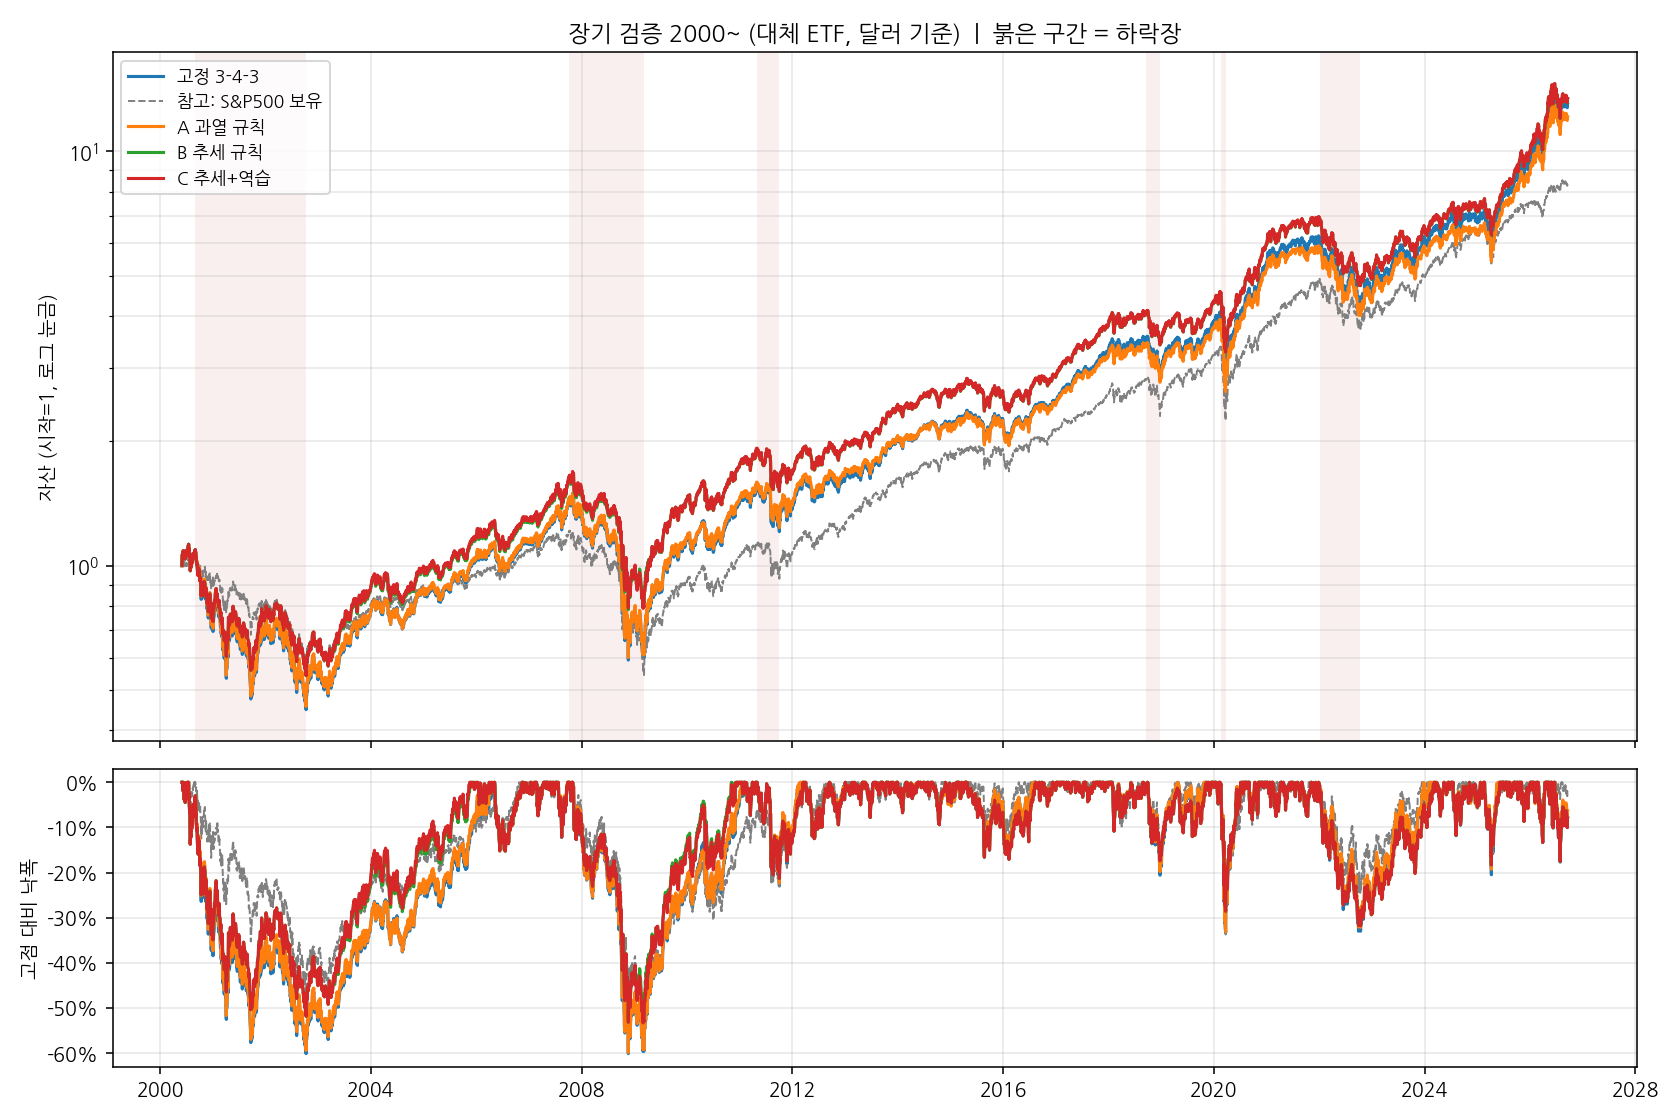

In [14]:
fig = longterm.plot(results_m, demo=DEMO); plt.close(fig)
display(Image(filename="output/longterm.png"))

### 🔍 판정 기준
전환 규칙을 **계속 쓸 가치가 있다**고 보려면 아래를 모두 만족해야 합니다.
1. 하락장 6번 중 **4번 이상** 고정 3-4-3보다 덜 잃었다 (한두 번 운이 아님)
2. 샤프지수가 고정 3-4-3보다 **뚜렷하게** 높다 (0.1 이상 차이)
3. 월 점검·분기 점검 **둘 다**에서 1, 2가 유지된다
4. 연평균 회전율이 과하지 않다 (높을수록 세금·수수료 부담 — 해외주식 양도세 22% 미반영)

만족하는 규칙이 없다면 → **고정 3-4-3 + 연 1회 리밸런싱**이 정답입니다.

## ⑦ 엔진 검증 테스트

In [15]:
%%writefile test_engine.py
"""최소 검증: python -m pytest -q  (또는 python test_engine.py)"""
import numpy as np
import pandas as pd

import config as C
import engine
import strategy
from data import demo_prices


def test_single_asset_matches_price():
    p, _ = demo_prices()
    r = engine.run(p, {"GOOGL": 1.0}, cost_bps=0)
    assert np.isclose(r.equity.iloc[-1] / r.equity.iloc[0], p["GOOGL"].iloc[-1] / p["GOOGL"].iloc[0])


def test_weights_sum_to_one():
    p, s = demo_prices()
    sch = strategy.formation_schedule(s, engine.check_dates(p.index, C.REBALANCE_FREQ))
    r = engine.run(p, sch)
    assert np.allclose(r.weights.iloc[1:].sum(axis=1), 1.0)


def test_no_lookahead():
    """미래 신호를 바꿔도 과거 포메이션은 바뀌지 않아야 한다."""
    p, s = demo_prices()
    checks = engine.check_dates(p.index, C.REBALANCE_FREQ)
    cut = checks[len(checks) // 2]
    s2 = s.copy()
    s2[s2.index > cut] *= 3
    a = strategy.formation_schedule(s, checks)
    b = strategy.formation_schedule(s2, checks)
    assert (a[a.index <= cut] == b[b.index <= cut]).all()


if __name__ == "__main__":
    for name, fn in list(globals().items()):
        if name.startswith("test_"):
            fn(); print("통과:", name)


Writing test_engine.py


In [16]:
!python test_engine.py

통과: test_single_asset_matches_price
통과: test_weights_sum_to_one
통과: test_no_lookahead


## ⑧ 결과 다운로드 (csv + 차트)

In [17]:
import shutil
shutil.make_archive("backtest_output", "zip", "output")
if IN_COLAB:
    from google.colab import files
    files.download("backtest_output.zip")
else:
    print("backtest_output.zip 저장됨")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 결과 해석 전 꼭 기억할 것
- **종목 선택 편향**: HPE·노키아·현대모비스는 2026년 시점에 고른 종목입니다. 2016년 투자자는 몰랐으므로 과거 성과가 부풀려질 수 있습니다.
- **짧은 기간**: 전환이 10번 안팎이면 통계적으로 확신하기 어렵습니다.
- **세금 미반영**: 해외주식 양도세(연 250만원 공제 후 22%)는 반영하지 않았습니다.

**다음 실험 아이디어**: `SIGNAL_TICKER = "^KS11"`(코스피 신호) · `REBALANCE_FREQ = "ME"`(월간 점검) · 기간을 반으로 나눠 표본 외 검증 · 뉴스 감성 신호 추가